# Task 3.2 Selling Signal Identification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization,
    Input, Bidirectional, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.17.1


## 1. Load and Inspect Data

In [2]:
DATA_PATH = '/Users/tanle/Downloads/Spring2026/CS313/DL4AI-220176-project/data-vn-20230228/stock-historical-data/HSG-VNINDEX-History.csv'

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (3551, 7)
Columns: ['Unnamed: 0', 'Open', 'High', 'Low', 'Close', 'Volume', 'TradingDate']


,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate
0,0,2532.0,2532.0,2532.0,2532.0,10110,2008-12-05
1,1,2531.0,2532.0,2405.0,2405.0,6570,2008-12-08
2,2,2286.0,2286.0,2286.0,2286.0,10,2008-12-09
3,3,2176.0,2176.0,2176.0,2176.0,10,2008-12-10
4,4,2073.0,2073.0,2073.0,2073.0,460,2008-12-11


In [3]:
col_map = {}
for c in df.columns:
    cl = c.strip().lower()
    if 'date' in cl or 'time' in cl:
        col_map[c] = 'Date'
    elif cl == 'open':
        col_map[c] = 'Open'
    elif cl == 'high':
        col_map[c] = 'High'
    elif cl == 'low':
        col_map[c] = 'Low'
    elif 'close' in cl and 'adj' not in cl:
        col_map[c] = 'Close'
    elif 'vol' in cl:
        col_map[c] = 'Volume'

df.rename(columns=col_map, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

df.dropna(subset=['Open', 'High', 'Low', 'Close'], inplace=True)
df.reset_index(drop=True, inplace=True)

print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Total rows:', len(df))
df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].tail()

Date range: 2008-12-05 00:00:00 to 2023-02-28 00:00:00
Total rows: 3551


,Date,Open,High,Low,Close,Volume
3546,2023-02-22,15500.0,16400.0,15000.0,15000.0,36714477
3547,2023-02-23,15150.0,15800.0,14500.0,15800.0,23890900
3548,2023-02-24,15800.0,15950.0,15000.0,15200.0,13662845
3549,2023-02-27,14800.0,15000.0,14400.0,14400.0,20537057
3550,2023-02-28,14800.0,14900.0,14300.0,14550.0,9112588


## 2. Feature indicators

In [4]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    histogram = macd - signal_line
    return macd, signal_line, histogram

def compute_bollinger(series, window=20, num_std=2):
    sma = series.rolling(window).mean()
    std = series.rolling(window).std()
    upper = sma + num_std * std
    lower = sma - num_std * std
    pct_b = (series - lower) / (upper - lower + 1e-9)
    return upper, lower, pct_b

def compute_stochastic(high, low, close, k_period=14, d_period=3):
    lowest_low = low.rolling(k_period).min()
    highest_high = high.rolling(k_period).max()
    k = 100 * (close - lowest_low) / (highest_high - lowest_low + 1e-9)
    d = k.rolling(d_period).mean()
    return k, d

close = df['Close']
high  = df['High']
low   = df['Low']

df['SMA_5']   = close.rolling(5).mean()
df['SMA_10']  = close.rolling(10).mean()
df['SMA_20']  = close.rolling(20).mean()
df['EMA_12']  = close.ewm(span=12, adjust=False).mean()
df['EMA_26']  = close.ewm(span=26, adjust=False).mean()

df['RSI_14']  = compute_rsi(close, 14)

df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = compute_macd(close)

df['BB_Upper'], df['BB_Lower'], df['BB_PctB'] = compute_bollinger(close)

df['Stoch_K'], df['Stoch_D'] = compute_stochastic(high, low, close)

df['Return_1d']  = close.pct_change(1)
df['Return_3d']  = close.pct_change(3)
df['Volatility'] = df['Return_1d'].rolling(10).std()

if 'Volume' in df.columns:
    df['Volume_MA5'] = df['Volume'].rolling(5).mean()
    df['Volume_Ratio'] = df['Volume'] / (df['Volume_MA5'] + 1e-9)

df['Price_Range'] = (high - low) / (close + 1e-9)

print('Features computed. Shape:', df.shape)

Features computed. Shape: (3551, 27)


## 3. Define sell signal label

**Sell signal = 1** if the closing price falls by more than `DROP_THRESHOLD` (e.g., 2%) within the next `FORWARD_DAYS` trading days.

This mimics real-world logic: a sell signal fires when a significant price drop is coming.

In [5]:
FORWARD_DAYS   = 5
DROP_THRESHOLD = 0.02

future_min = close.shift(-FORWARD_DAYS).rolling(FORWARD_DAYS).min().shift(-(FORWARD_DAYS - 1))

future_min_price = pd.Series(index=df.index, dtype=float)
for i in range(len(df) - FORWARD_DAYS):
    future_min_price.iloc[i] = df['Close'].iloc[i+1 : i+1+FORWARD_DAYS].min()

df['Future_Min'] = future_min_price
df['Future_Return'] = (df['Future_Min'] - close) / (close + 1e-9)
df['Sell_Signal'] = (df['Future_Return'] < -DROP_THRESHOLD).astype(int)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

sell_rate = df['Sell_Signal'].mean()
print(f'Total samples: {len(df)}')
print(f'Sell signal rate: {sell_rate:.2%}  (1={df["Sell_Signal"].sum()}, 0={len(df)-df["Sell_Signal"].sum()})')

Total samples: 3527
Sell signal rate: 50.38%  (1=1777, 0=1750)


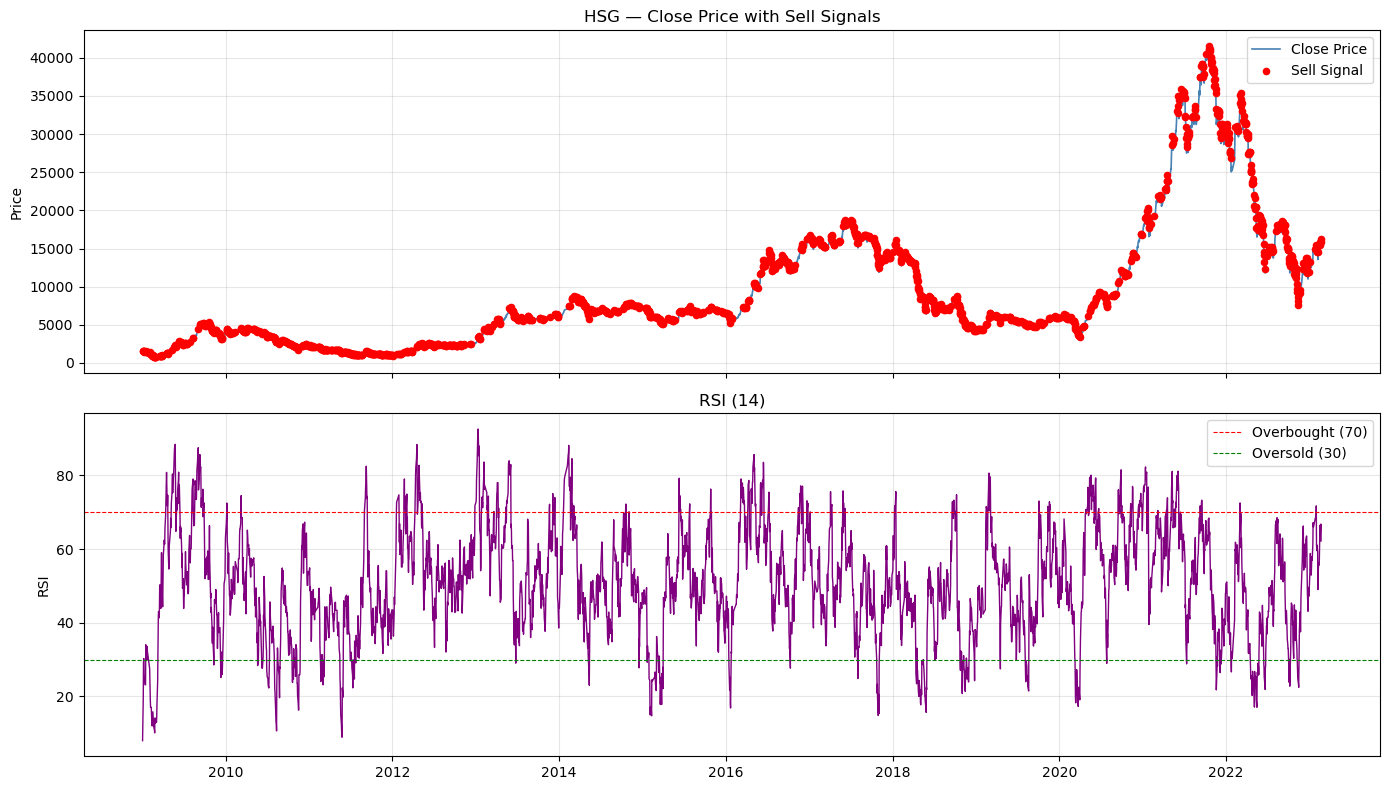

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df['Date'], df['Close'], color='steelblue', linewidth=1.2, label='Close Price')
sell_days = df[df['Sell_Signal'] == 1]
axes[0].scatter(sell_days['Date'], sell_days['Close'], color='red', s=20, zorder=5, label='Sell Signal')
axes[0].set_title('HSG — Close Price with Sell Signals')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df['Date'], df['RSI_14'], color='purple', linewidth=1)
axes[1].axhline(70, color='red', linestyle='--', linewidth=0.8, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
axes[1].set_title('RSI (14)')
axes[1].set_ylabel('RSI')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Feature Selection and Scaling

In [7]:
FEATURE_COLS = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'SMA_5', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26',
    'RSI_14',
    'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_PctB',
    'Stoch_K', 'Stoch_D',
    'Return_1d', 'Return_3d', 'Volatility',
    'Volume_Ratio', 'Price_Range'
]

FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f'Using {len(FEATURE_COLS)} features:', FEATURE_COLS)

Using 22 features: ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_5', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_PctB', 'Stoch_K', 'Stoch_D', 'Return_1d', 'Return_3d', 'Volatility', 'Volume_Ratio', 'Price_Range']


## 5. Time-Series train / validation / test split

Chronological split — NO shuffling:
- Train: first 70%
- Validation: next 15%
- Test: last 15%

In [8]:
WINDOW_SIZE = 20

n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

print(f'Total: {n} | Train: {train_end} | Val: {val_end - train_end} | Test: {n - val_end}')
print(f'Train: {df["Date"].iloc[0].date()} → {df["Date"].iloc[train_end-1].date()}')
print(f'Val:   {df["Date"].iloc[train_end].date()} → {df["Date"].iloc[val_end-1].date()}')
print(f'Test:  {df["Date"].iloc[val_end].date()} → {df["Date"].iloc[-1].date()}')

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

scaler = MinMaxScaler()
X_train_raw = scaler.fit_transform(train_df[FEATURE_COLS])
X_val_raw   = scaler.transform(val_df[FEATURE_COLS])
X_test_raw  = scaler.transform(test_df[FEATURE_COLS])

y_train_raw = train_df['Sell_Signal'].values
y_val_raw   = val_df['Sell_Signal'].values
y_test_raw  = test_df['Sell_Signal'].values

Total: 3527 | Train: 2468 | Val: 529 | Test: 530
Train: 2009-01-02 → 2018-11-21
Val:   2018-11-22 → 2020-12-31
Test:  2021-01-04 → 2023-02-21


In [9]:
def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train, y_train = create_sequences(X_train_raw, y_train_raw, WINDOW_SIZE)
X_val,   y_val   = create_sequences(X_val_raw,   y_val_raw,   WINDOW_SIZE)
X_test,  y_test  = create_sequences(X_test_raw,  y_test_raw,  WINDOW_SIZE)

print(f'X_train: {X_train.shape} | y_train sell rate: {y_train.mean():.2%}')
print(f'X_val:   {X_val.shape}   | y_val   sell rate: {y_val.mean():.2%}')
print(f'X_test:  {X_test.shape}  | y_test  sell rate: {y_test.mean():.2%}')

X_train: (2448, 20, 22) | y_train sell rate: 49.51%
X_val:   (509, 20, 22)   | y_val   sell rate: 46.76%
X_test:  (510, 20, 22)  | y_test  sell rate: 56.08%


## 6. Handle Class Imbalance

Sell signals are typically a minority class. We use **class weights** to penalize misclassification of sell signals more heavily.

In [10]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
weight_for_0 = 1.0
weight_for_1 = n_neg / (n_pos + 1e-9)
class_weight = {0: weight_for_0, 1: weight_for_1}
print(f'Class weights — 0 (hold): {weight_for_0:.2f}, 1 (sell): {weight_for_1:.2f}')

Class weights — 0 (hold): 1.00, 1 (sell): 1.02


## 7. Build Bidirectional LSTM Model

A Bidirectional LSTM captures both past and future context within the window, which helps identify patterns that precede a sell event.

In [11]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)

    x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(32, return_sequences=False))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)

    output = Dense(1, activation='sigmoid', name='sell_probability')(x)

    model = Model(inputs, output)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )
    return model

model = build_model((WINDOW_SIZE, len(FEATURE_COLS)))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 22)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 20, 128)        │        44,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sell_probability (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,641 (346.25 KB)

 Trainable params: 88,257 (344.75 KB)

 Non-trainable params: 384 (1.50 KB)

## 8. Train the Model

In [12]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=15, mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.5352 - auc: 0.5402 - loss: 0.8341 - precision: 0.5194 - recall: 0.6476 - val_accuracy: 0.4695 - val_auc: 0.5263 - val_loss: 0.6930 - val_precision: 0.4175 - val_recall: 0.3403 - learning_rate: 0.0010
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.5358 - auc: 0.5543 - loss: 0.7567 - precision: 0.5471 - recall: 0.5431 - val_accuracy: 0.4912 - val_auc: 0.5075 - val_loss: 0.6931 - val_precision: 0.4575 - val_recall: 0.4748 - learning_rate: 0.0010
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5285 - auc: 0.5376 - loss: 0.7430 - precision: 0.5318 - recall: 0.4960 - val_accuracy: 0.4695 - val_auc: 0.5004 - val_loss: 0.6953 - val_precision: 0.4328 - val_recall: 0.4328 - learning_rate: 0.0010
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5715 - auc: 0.5821 - loss: 0.7154 - precision: 0.5561 - recall: 0.5589 - val_accuracy: 0.4695 - val_auc: 0.5101 - val_loss: 0.7025 - va

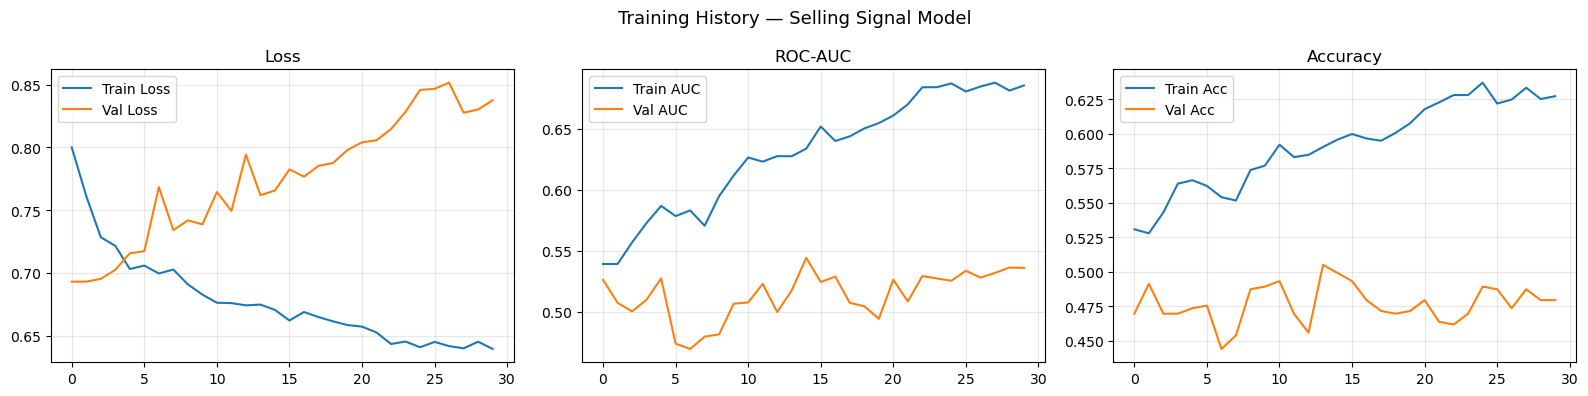

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('ROC-AUC')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history.history['accuracy'], label='Train Acc')
axes[2].plot(history.history['val_accuracy'], label='Val Acc')
axes[2].set_title('Accuracy')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Training History — Selling Signal Model', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Optimal Threshold Selection

Instead of using the default 0.5 threshold, we find the threshold that maximizes F1 on the **validation set**.

Best threshold (val F1): 0.10  |  Val F1: 0.6372


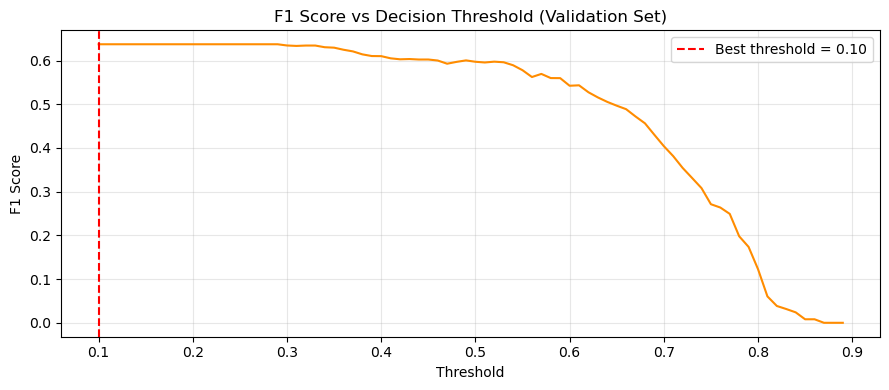

In [14]:
y_val_prob = model.predict(X_val, verbose=0).flatten()

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_val, (y_val_prob >= t).astype(int), zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1_val    = max(f1_scores)
print(f'Best threshold (val F1): {best_threshold:.2f}  |  Val F1: {best_f1_val:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, color='darkorange')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.title('F1 Score vs Decision Threshold (Validation Set)')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Test Set Evaluation

In [15]:
y_test_prob = model.predict(X_test, verbose=0).flatten()
y_test_pred = (y_test_prob >= best_threshold).astype(int)

auc_score = roc_auc_score(y_test, y_test_prob)

print('=' * 50)
print('TEST SET RESULTS')
print('=' * 50)
print(f'ROC-AUC Score: {auc_score:.4f}')
print(f'Decision Threshold: {best_threshold:.2f}')
print()
print(classification_report(y_test, y_test_pred, target_names=['Hold (0)', 'Sell (1)']))

TEST SET RESULTS
ROC-AUC Score: 0.4619
Decision Threshold: 0.10

              precision    recall  f1-score   support

    Hold (0)       0.00      0.00      0.00       224
    Sell (1)       0.56      1.00      0.72       286

    accuracy                           0.56       510
   macro avg       0.28      0.50      0.36       510
weighted avg       0.31      0.56      0.40       510



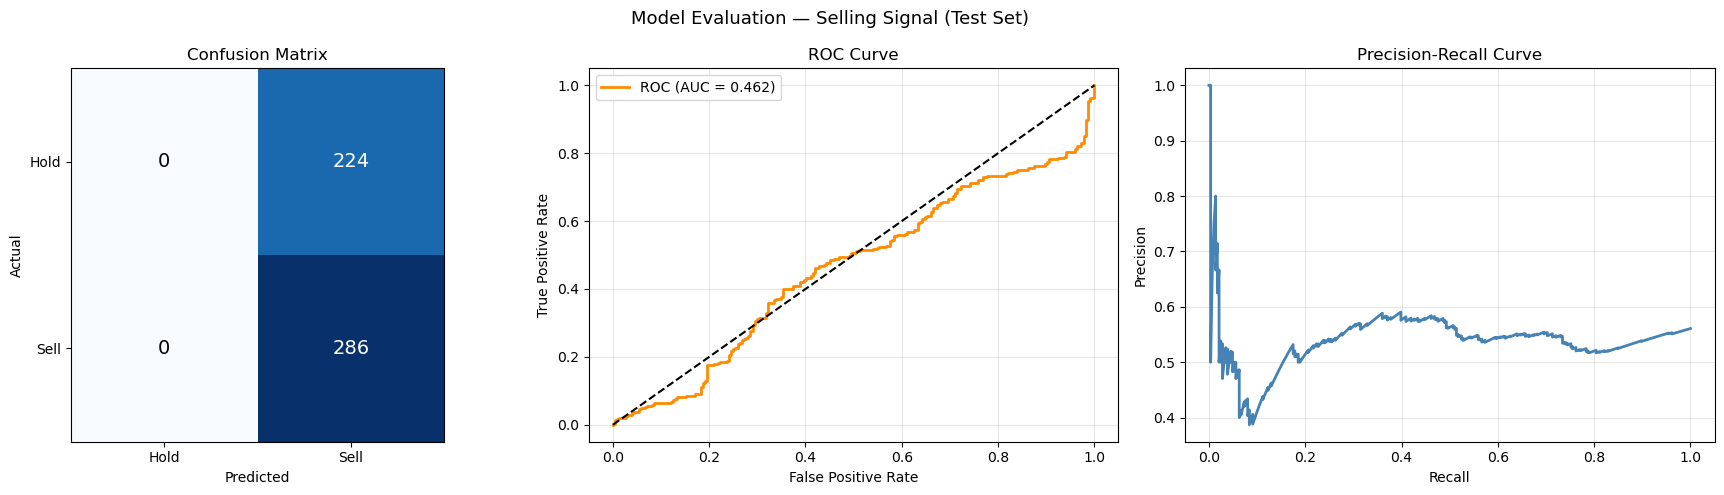

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_test_pred)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Hold', 'Sell'])
axes[0].set_yticklabels(['Hold', 'Sell'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, y_test_prob)
axes[2].plot(rec, prec, color='steelblue', lw=2)
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].grid(alpha=0.3)

plt.suptitle('Model Evaluation — Selling Signal (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Visualize Sell Signals on Price Chart

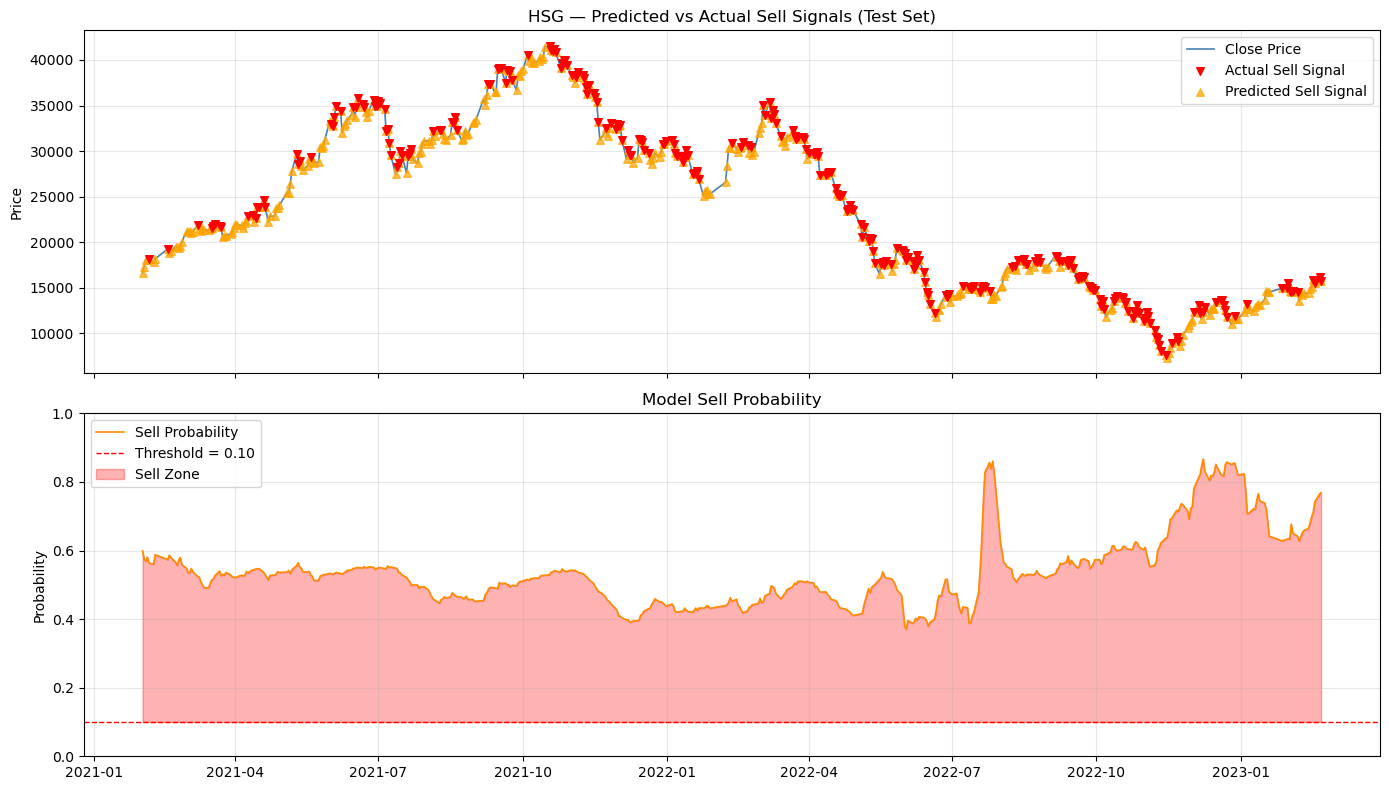

In [17]:
test_dates = df['Date'].iloc[val_end + WINDOW_SIZE:].reset_index(drop=True)
test_close = df['Close'].iloc[val_end + WINDOW_SIZE:].reset_index(drop=True)

min_len = min(len(test_dates), len(y_test_prob))
test_dates    = test_dates[:min_len]
test_close    = test_close[:min_len]
y_test_prob_  = y_test_prob[:min_len]
y_test_pred_  = y_test_pred[:min_len]
y_test_actual = y_test[:min_len]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(test_dates, test_close, color='steelblue', linewidth=1.2, label='Close Price')

pred_sell_idx   = np.where(y_test_pred_ == 1)[0]
actual_sell_idx = np.where(y_test_actual == 1)[0]

axes[0].scatter(test_dates.iloc[actual_sell_idx], test_close.iloc[actual_sell_idx],
                color='red', s=30, zorder=5, label='Actual Sell Signal', marker='v')
axes[0].scatter(test_dates.iloc[pred_sell_idx], test_close.iloc[pred_sell_idx],
                color='orange', s=30, zorder=4, label='Predicted Sell Signal', marker='^', alpha=0.7)

axes[0].set_title('HSG — Predicted vs Actual Sell Signals (Test Set)')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(test_dates, y_test_prob_, color='darkorange', linewidth=1.2, label='Sell Probability')
axes[1].axhline(best_threshold, color='red', linestyle='--', linewidth=1,
                label=f'Threshold = {best_threshold:.2f}')
axes[1].fill_between(test_dates, y_test_prob_, best_threshold,
                     where=(y_test_prob_ >= best_threshold), alpha=0.3, color='red', label='Sell Zone')
axes[1].set_title('Model Sell Probability')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Rolling window cross-validation

We use **rolling/expanding window** cross-validation — appropriate for time series. No random K-fold.

In [18]:
def rolling_cv(X_all, y_all, n_splits=3, min_train_size=0.5):
    n = len(X_all)
    step = int(n * (1 - min_train_size) / (n_splits + 1))
    train_start = int(n * min_train_size)

    cv_results = []
    for fold in range(n_splits):
        val_start = train_start + fold * step
        val_end_  = val_start + step
        if val_end_ > n:
            break

        X_tr, y_tr = X_all[:val_start], y_all[:val_start]
        X_vl, y_vl = X_all[val_start:val_end_], y_all[val_start:val_end_]

        n_neg_ = (y_tr == 0).sum()
        n_pos_ = (y_tr == 1).sum()
        cw = {0: 1.0, 1: max(1.0, n_neg_ / (n_pos_ + 1e-9))}

        cv_model = build_model((WINDOW_SIZE, len(FEATURE_COLS)))
        cv_model.fit(
            X_tr, y_tr,
            validation_data=(X_vl, y_vl),
            epochs=50, batch_size=32, class_weight=cw,
            callbacks=[EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True)],
            verbose=0
        )

        prob = cv_model.predict(X_vl, verbose=0).flatten()
        if y_vl.sum() == 0 or y_vl.sum() == len(y_vl):
            auc = float('nan')
        else:
            auc = roc_auc_score(y_vl, prob)
        f1  = f1_score(y_vl, (prob >= 0.5).astype(int), zero_division=0)

        cv_results.append({'fold': fold+1, 'train_size': len(X_tr), 'val_size': len(X_vl), 'AUC': auc, 'F1': f1})
        print(f'Fold {fold+1}: train={len(X_tr)}, val={len(X_vl)}, AUC={auc:.4f}, F1={f1:.4f}')

    return pd.DataFrame(cv_results)

X_all = np.concatenate([X_train, X_val, X_test], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)

print('Running rolling window cross-validation...')
cv_df = rolling_cv(X_all, y_all, n_splits=3, min_train_size=0.5)
print('\nCV Summary:')
print(cv_df)
print(f'\nMean AUC: {cv_df["AUC"].mean():.4f} ± {cv_df["AUC"].std():.4f}')
print(f'Mean F1:  {cv_df["F1"].mean():.4f} ± {cv_df["F1"].std():.4f}')

Running rolling window cross-validation...
Fold 1: train=1733, val=433, AUC=0.5950, F1=0.5504
Fold 2: train=2166, val=433, AUC=0.5525, F1=0.0524
Fold 3: train=2599, val=433, AUC=0.6217, F1=0.6084

CV Summary:
   fold  train_size  val_size       AUC        F1
0     1        1733       433  0.595028  0.550427
1     2        2166       433  0.552523  0.052434
2     3        2599       433  0.621711  0.608365

Mean AUC: 0.5898 ± 0.0349
Mean F1:  0.4037 ± 0.3056


## 13. Save model

In [19]:
model.save('selling_signal_model.keras')
print('Model saved to selling_signal_model.keras')

import pickle
with open('selling_signal_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved to selling_signal_scaler.pkl')

Model saved to selling_signal_model.keras
Scaler saved to selling_signal_scaler.pkl


## 14. Predict sell signal for latest data

In [20]:
latest_window = df[FEATURE_COLS].values[-WINDOW_SIZE:]
latest_scaled = scaler.transform(latest_window)
latest_input  = latest_scaled[np.newaxis, :, :]

sell_prob = model.predict(latest_input, verbose=0)[0][0]
signal    = 'SELL' if sell_prob >= best_threshold else 'HOLD'

print(f'Latest date: {df["Date"].iloc[-1].date()}')
print(f'Sell probability: {sell_prob:.4f}')
print(f'Signal: {signal}')
print(f'(Threshold: {best_threshold:.2f})')

Latest date: 2023-02-21
Sell probability: 0.7607
Signal: SELL
(Threshold: 0.10)


---
## Summary

| Component | Choice | Justification |
|---|---|---|
| **Label** | Price drop > 2% within 5 days = Sell | Captures short-term downside risk; threshold tunable |
| **Features** | OHLCV + RSI, MACD, Bollinger, Stochastic, SMA/EMA | Standard technical indicators proven in quantitative finance |
| **Model** | Bidirectional LSTM | Captures temporal dependencies in both directions within the window |
| **Imbalance** | Class weights | Avoids the model always predicting "Hold" |
| **Threshold** | F1-maximized on validation set | More robust than default 0.5 for imbalanced classes |
| **Validation** | Chronological 70/15/15 split + rolling window CV | Respects time-series structure, no data leakage |
| **Metrics** | F1, Precision, Recall, ROC-AUC | Balanced evaluation for imbalanced binary classification |